In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In this project we are using pandas library for data handling & analysis or to convert data ino table format, Filtering, Grouping,
Aggregation made easy or loading dataset so pandas was useful for efficient data manipulation, exploration and summarization of
structure tabular data this or we install pandas using this command "pip install pandas" in jupyter notebook.

also I'm using NumPy for numerical computations and efficient array-based operations on large dataset install this using command
"pip install NumPy".

also matplotlib is python core plotting library used for visualization for understanding data distribution and trend
install this using command "pip install matplotlib.pyplot".

also using seaborn for advanced & statistical visualization less code gives better looking plots or that makes patterns 
and relationship easier to interpret install this using command "pip install seaborn".

In [2]:
data = "D:\Diseases_and_Symptoms_dataset\Diseases_and_Symptoms_dataset.csv"
df = pd.read_csv(data)
df.head()

<>:1: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:1: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
C:\Users\ruchi\AppData\Local\Temp\ipykernel_6248\1048860038.py:1: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
  data = "D:\Diseases_and_Symptoms_dataset\Diseases_and_Symptoms_dataset.csv"


,diseases,anxiety and nervousness,depression,shortness of breath,depressive or psychotic symptoms,sharp chest pain,dizziness,insomnia,abnormal involuntary movements,chest tightness,...,stuttering or stammering,problems with orgasm,nose deformity,lump over jaw,sore in nose,hip weakness,back swelling,ankle stiffness or tightness,ankle weakness,neck weakness
0,panic disorder,1,0,1,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,panic disorder,0,0,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,panic disorder,1,1,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,panic disorder,1,0,0,1,0,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
4,panic disorder,1,1,0,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0


Here we load the dataset

In [3]:
df.tail()

,diseases,anxiety and nervousness,depression,shortness of breath,depressive or psychotic symptoms,sharp chest pain,dizziness,insomnia,abnormal involuntary movements,chest tightness,...,stuttering or stammering,problems with orgasm,nose deformity,lump over jaw,sore in nose,hip weakness,back swelling,ankle stiffness or tightness,ankle weakness,neck weakness
246940,open wound of the nose,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
246941,open wound of the nose,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
246942,open wound of the nose,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
246943,open wound of the nose,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
246944,open wound of the nose,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
df.isnull().sum().sum()

np.int64(0)

This dataset does not contain any null value.

In [5]:
df.shape

(246945, 378)

This dataset contains 246945 records and 378 variables, indicating a large, high-dimensional dataset suitable for pattern discovery  

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246945 entries, 0 to 246944
Columns: 378 entries, diseases to neck weakness
dtypes: int64(377), object(1)
memory usage: 712.2+ MB


Most variables are binary symptom indicators while the disease column is categorical. This confirms that the dataset represents presence or absence of symptoms rather than severity.

In [7]:
df['diseases'].value_counts()

diseases
cystitis                          1219
nose disorder                     1218
vulvodynia                        1218
complex regional pain syndrome    1217
spondylosis                       1216
                                  ... 
open wound of the head               1
myocarditis                          1
chronic ulcer                        1
hypergammaglobulinemia               1
kaposi sarcoma                       1
Name: count, Length: 773, dtype: int64

certain diseases dominate the dataset, indicating class imbalance, which may affect model training and requires careful handling

In [8]:
symptom_cols = df.columns.drop('diseases')
df[symptom_cols] = df[symptom_cols].astype('int8')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246945 entries, 0 to 246944
Columns: 378 entries, diseases to neck weakness
dtypes: int8(377), object(1)
memory usage: 90.7+ MB


In [ ]:
df["diseases"].unique()

np.int64(246945)

In [ ]:
print("unique values", df["diseases"].nunique())
print("Total count of diseases", df["diseases"].count())

unique values 773
Total count of diseases 246945


This process describe all unique diseases name and we see that we have 773 unque values that means we have 773 types diseases or that 773 diseases occurs in 246945 people .

In [17]:
top_diseases = df["diseases"].value_counts().head(30)
top_diseases

diseases
cystitis                              1219
nose disorder                         1218
vulvodynia                            1218
complex regional pain syndrome        1217
spondylosis                           1216
vaginal cyst                          1215
esophagitis                           1215
peripheral nerve disorder             1215
hypoglycemia                          1215
conjunctivitis due to allergy         1215
gastrointestinal hemorrhage           1214
diverticulitis                        1214
acute bronchitis                      1213
infectious gastroenteritis            1212
fungal infection of the hair          1212
sprain or strain                      1212
pneumonia                             1212
spontaneous abortion                  1212
gout                                  1211
marijuana abuse                       1210
arthritis of the hip                  1210
strep throat                          1210
injury to the arm                     1209
li

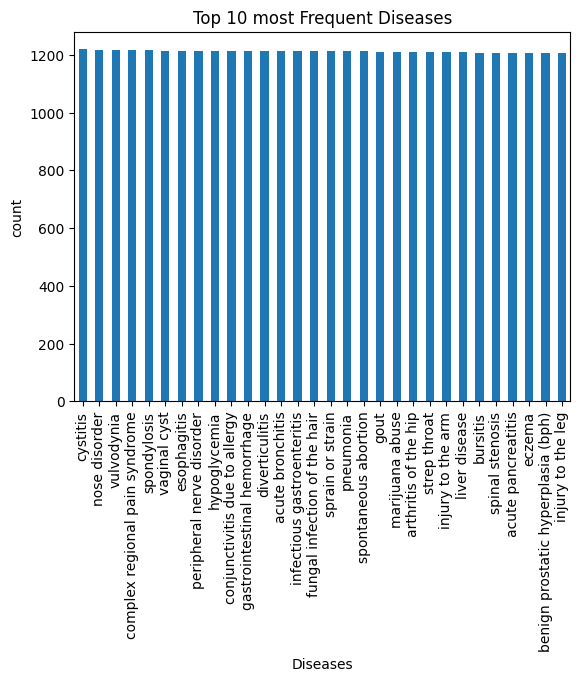

In [18]:
top_diseases.plot(kind='bar')
plt.title('Top 10 most Frequent Diseases')
plt.xlabel('Diseases')
plt.ylabel('count')
plt.show()

Symptoms Frequency

In [13]:
symptom_frequency = df[symptom_cols].sum().sort_values(ascending = False)
symptom_frequency.head(25)

sharp abdominal pain                32307
vomiting                            27874
headache                            24719
cough                               24296
sharp chest pain                    24016
nausea                              23687
back pain                           21809
shortness of breath                 21346
fever                               20394
dizziness                           17272
abnormal appearing skin             16425
nasal congestion                    16200
leg pain                            16189
skin swelling                       15165
depressive or psychotic symptoms    15064
lower abdominal pain                14936
sore throat                         14005
burning abdominal pain              12981
skin rash                           12375
skin lesion                         12340
arm pain                            11619
weakness                            11551
low back pain                       11053
ear pain                          

A small subset of symptoms appears very frequently, while most symptoms are rare.

Anomalies Detection

In [14]:
df["symptom_cols"] = df[symptom_cols].sum(axis=1)
df["symptom_cols"].describe()

C:\Users\ruchi\AppData\Local\Temp\ipykernel_9660\3770135631.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["symptom_cols"] = df[symptom_cols].sum(axis=1)


count    246945.000000
mean          5.332851
std           1.640610
min           1.000000
25%           4.000000
50%           5.000000
75%           6.000000
max          12.000000
Name: symptom_cols, dtype: float64

<Axes: >

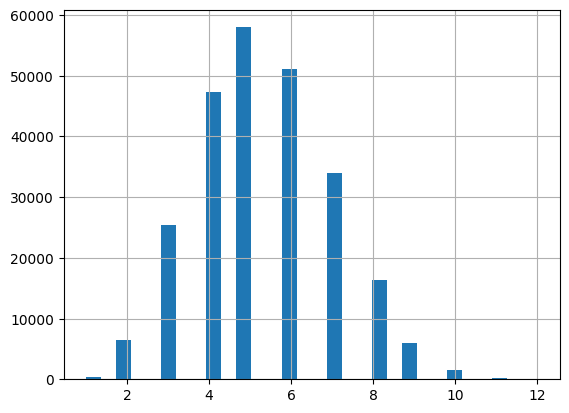

In [15]:
df["symptom_cols"].hist(bins=30)

The number of symptoms per patient is right-skewed, with most records having a limited number of symptoms and a few cases showing unusually high counts, suggestion possible complex or overlapping condition.

In [18]:
df.groupby("diseases")["symptom_cols"].mean().sort_values(ascending=False).head(25)

diseases
hiatal hernia                         6.300221
temporary or benign blood in urine    6.264214
anxiety                               6.095159
concussion                            6.090680
obstructive sleep apnea (osa)         6.086120
dental caries                         6.079325
injury to the leg                     6.076285
strep throat                          6.073554
acute bronchitis                      6.070899
marijuana abuse                       6.066942
gout                                  6.065235
acute pancreatitis                    6.060481
acute bronchiolitis                   6.058970
eczema                                6.057167
liver disease                         6.053763
cholecystitis                         6.049834
noninfectious gastroenteritis         6.048922
spinal stenosis                       6.046396
bursitis                              6.045530
sprain or strain                      6.044554
conjunctivitis due to allergy         6.044444
beni

By computing the average symptom count per disease, we identified diseases with higher symptom complexity, highlighting conditions that may be harder to diagnose due to multiple overlapping symptoms.

In [19]:
symptom_frequency.describe()

count      377.000000
mean      3493.159151
std       4881.086632
min          0.000000
25%        252.000000
50%       1797.000000
75%       4879.000000
max      32307.000000
dtype: float64

The exploratory data analysis revealed that the dataset is large, high-dimensional, and sparse, consisting mainly of binary symptom indicators along with a categorical disease label. The distribution of diseases is imbalanced, with certain conditions appearing far more frequently than others. Symptom occurrence is highly skewed, where a small subset of symptoms is common across multiple diseases while most symptoms are rare. The number of symptoms per record varies widely, indicating differences in disease complexity, as captured by the engineered symptom_count feature. These findings highlight key challenges such as data sparsity, class imbalance, and high dimensionality, which must be carefully addressed before applying predictive modeling techniques.